# 👥 Customer Segmentation Analysis
### Oasis Infobyte Data Analytics Internship — Project 2
**Author:** Nandini  
**Date:** May 2026

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 1️⃣ Data Exploration & Cleaning

In [5]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
df.describe()

(200, 5)
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2️⃣ Descriptive Statistics & Visualization

C:\Users\nandi\AppData\Local\Temp\ipykernel_37244\572524557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='Set2')


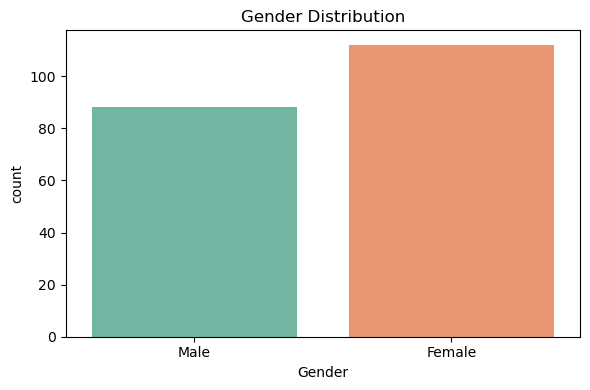

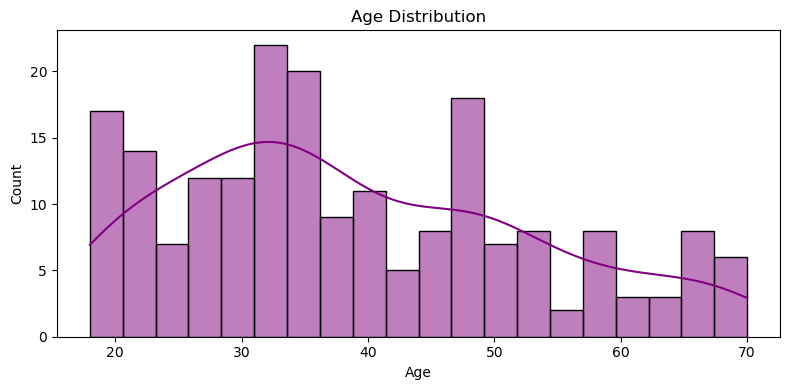

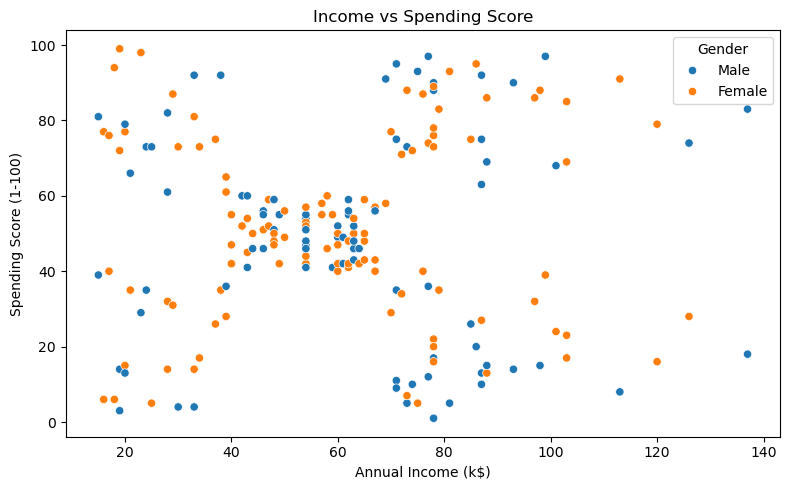

In [6]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True, color='purple')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

# Income vs Spending Score
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender')
plt.title('Income vs Spending Score')
plt.tight_layout()
plt.show()

## 3️⃣ Customer Segmentation — K-Means Clustering

C:\applications\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\applications\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\applications\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\applications\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chun

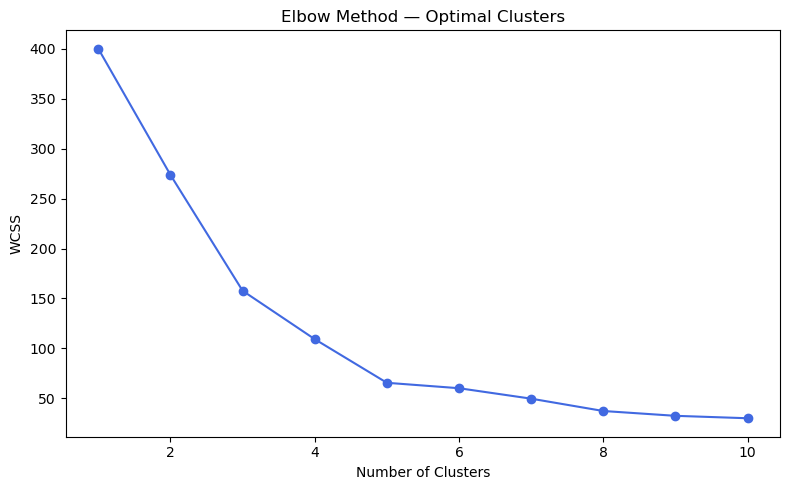

In [7]:
# Find optimal number of clusters using Elbow Method
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', color='royalblue')
plt.title('Elbow Method — Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.tight_layout()
plt.show()

## 4️⃣ Applying K-Means with 5 Clusters

C:\applications\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


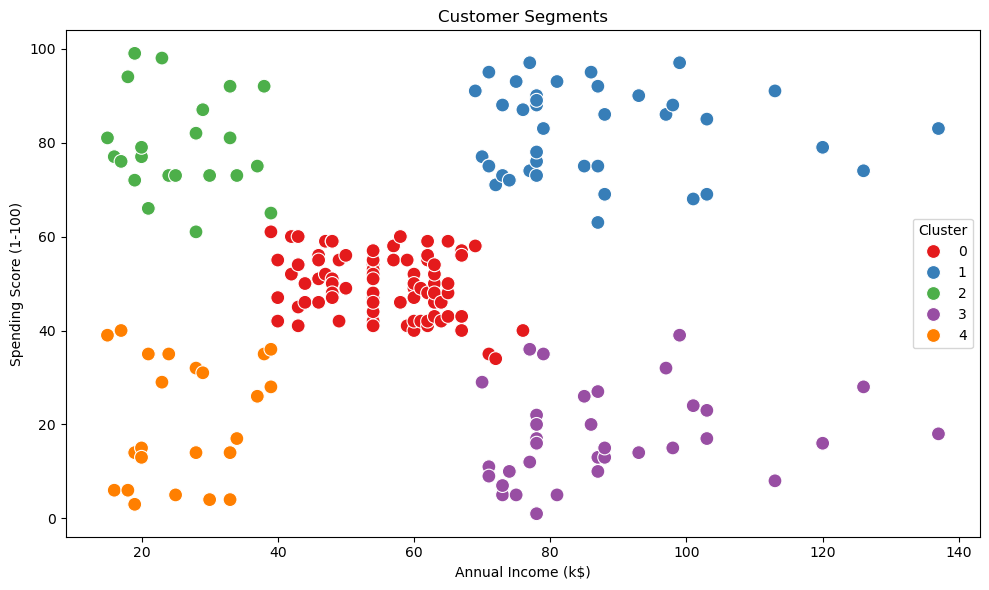

In [8]:
# Apply K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', data=df, palette='Set1', s=100)
plt.title('Customer Segments')
plt.tight_layout()
plt.show()

## 5️⃣ Cluster Analysis & Insights

In [9]:
print(df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean())

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


## 6️⃣ Recommendations

- 🟢 **Cluster 0 — High Income, High Spenders**: VIP customers — offer loyalty rewards
- 🔵 **Cluster 1 — Low Income, Low Spenders**: Budget customers — offer discounts
- 🔴 **Cluster 2 — High Income, Low Spenders**: Potential customers — targeted campaigns
- 🟡 **Cluster 3 — Low Income, High Spenders**: Impulsive buyers — limited time offers
- 🟣 **Cluster 4 — Average Income, Average Spenders**: Regular customers — retention programs

## ✅ Conclusion
K-Means clustering successfully segmented 200 customers into 5 distinct groups, enabling targeted marketing strategies for each segment.